In [1]:
import torch
from emulator.data_loader import load_dataset

data = torch.load("emulator/sigma_model/checkpoints/dataset_split.pt")
train_thetas, train_ps2d, train_xhi = data["train_thetas"], data["train_ps2d"], data["train_xhi"]
test_thetas,  test_ps2d,  test_xhi  = data["test_thetas"],  data["test_ps2d"],  data["test_xhi"]

In [2]:
train_thetas.shape, train_ps2d.shape, train_xhi.shape

(torch.Size([13105, 6]),
 torch.Size([13105, 3, 10, 10]),
 torch.Size([13105, 3]))

In [3]:
ps2d_scalar_try = train_ps2d.reshape(len(train_ps2d), -1)  # shape [N, 100*100]
ps2d_scalar_try.shape

torch.Size([13105, 300])

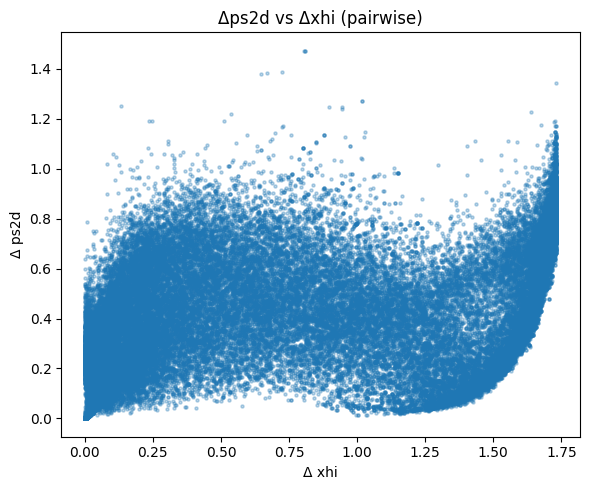

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Flatten xhi to a 1D scalar per sample (mean over all bins)
# Adjust if xhi has a specific structure (e.g. shape [N, k])
ps2d = remove_noise(train_ps2d.numpy())
ps2d_scalar = ps2d.reshape(len(ps2d), -1) # shape [N], mean over spatial dims
xhi_scalar = train_xhi.reshape(len(train_xhi), -1) # shape [N], mean over spatial dims
# Pairwise L2 distance on xhi
xhi_np  = train_xhi.numpy()
ps2d_np = ps2d_scalar
# Pick N_PAIRS random pairs, compute delta_xhi vs delta_ps2d
N = len(xhi_np)
N_PAIRS = 60000
rng = np.random.default_rng(42)
idx_i = rng.integers(0, N, N_PAIRS)
idx_j = rng.integers(0, N, N_PAIRS)



delta_xhi  = np.linalg.norm(xhi_np[idx_i] - xhi_np[idx_j], axis=1)  # L2 distance
delta_ps2d = np.linalg.norm(ps2d_np[idx_i] - ps2d_np[idx_j], axis=1)  # L2 distance

plt.figure(figsize=(6, 5))
plt.scatter(delta_xhi, delta_ps2d, s=5, alpha=0.3)
plt.xlabel("Δ xhi")
plt.ylabel("Δ ps2d")
plt.title("Δps2d vs Δxhi (pairwise)")
plt.tight_layout()
plt.show()
# → si ps2d dépend de xhi : nuage aligné sur y=0 quand Δxhi≈0


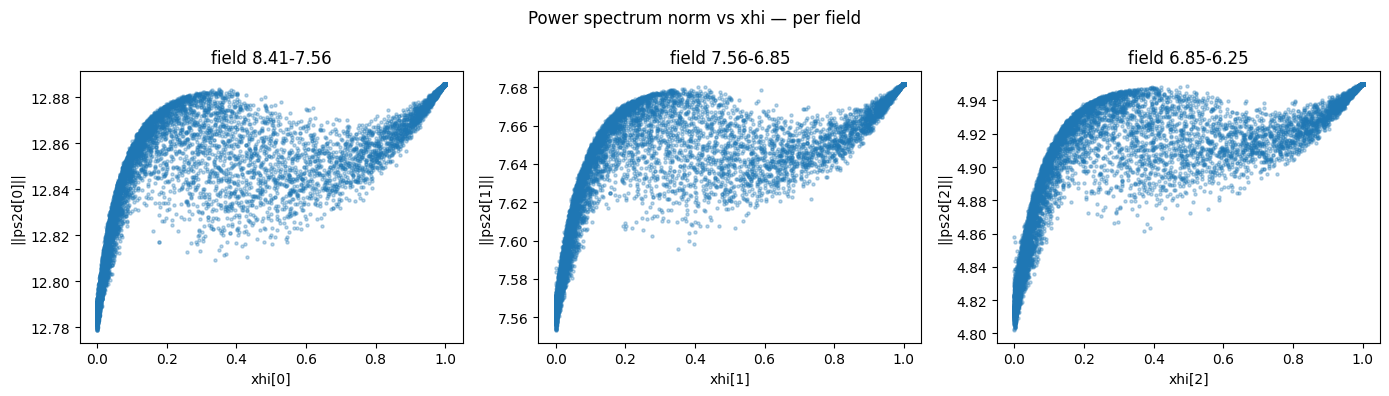

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# xhi  : [N, 3]         — 3 scalar values per sample
# ps2d : [N, 3, 10, 10] — 3 power spectra, each 10x10

# Norm of each 10x10 power spectrum → [N, 3]
ps2d = remove_noise(train_ps2d.numpy())
ps2d_norm = torch.from_numpy(ps2d).reshape(len(train_ps2d), 3, -1).norm(dim=-1, p=2)
xhi_np  = train_xhi.numpy()    # [N, 3]
ps2d_np = ps2d_norm.numpy()    # [N, 3]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
redshift = ['8.41-7.56', '7.56-6.85', '6.85-6.25']
for k, ax in enumerate(axes):
    ax.scatter(xhi_np[:, k], ps2d_np[:, k], s=5, alpha=0.3)
    ax.set_xlabel(f"xhi[{k}]")
    ax.set_ylabel(f"||ps2d[{k}]||")
    ax.set_title(f"redshift : {redshift[k]}")


plt.suptitle("Power spectrum norm vs xhi — per field")
plt.tight_layout()
plt.show()

In [10]:
def adding_instrumental_noise(ps2d_list):
    files_noise = sorted(glob("PS1_PS2_Data/Pk_PS_averaged_noise_*.txt"))
    for i, f in enumerate(files_noise):
        data_average_noise = np.loadtxt(f)
        ps2d_list[i] += data_average_noise
    return ps2d_list

def remove_noise(ps2d_lists,files_noise= None):
    '''ps2d_lists: [N,3,10, 10] with differents samples for each field'''
    if files_noise is None:
        from glob import glob
        files_noise = sorted(glob("PS1_PS2_Data/Pk_PS_averaged_noise_*.txt"))
    for i, f in enumerate(files_noise):
        data_average_noise = np.loadtxt(f)
        ps2d_lists[:,i] -= data_average_noise
    return ps2d_lists

In [39]:
ps2d_np.shape

(13105, 3)

field 0 : 2551 samples with xhi[0] > 0.99
2.9037225246429443
field 1 : 3180 samples with xhi[1] > 0.99
3.3990399837493896
field 2 : 3740 samples with xhi[2] > 0.99
3.4951047897338867


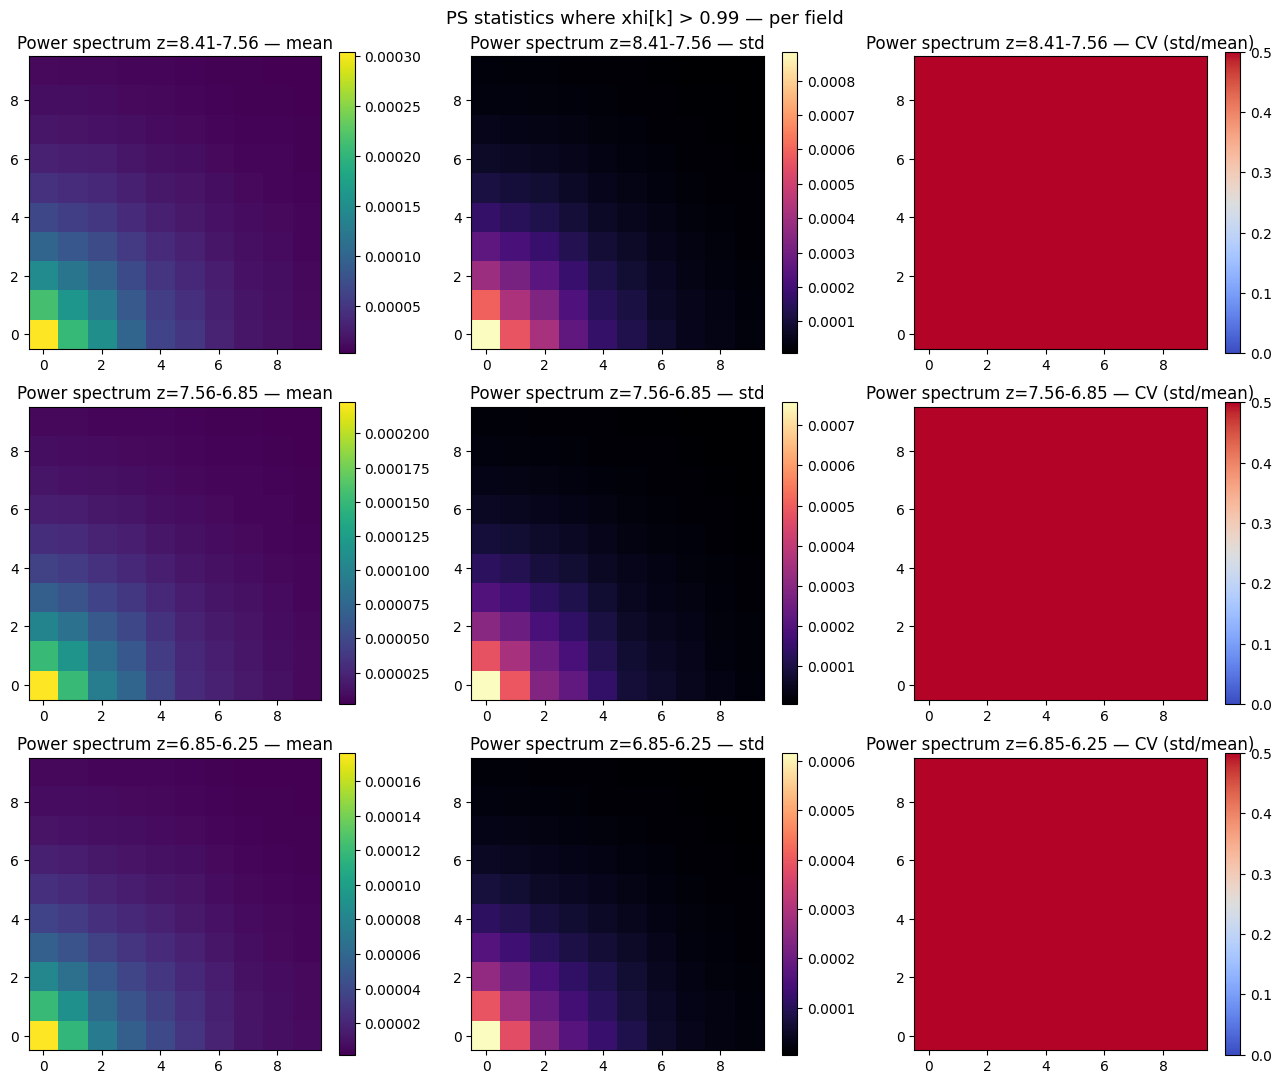

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
THRESHOLD = 0.99

field_names = ["Power spectrum z=8.41-7.56", "Power spectrum z=7.56-6.85", "Power spectrum z=6.85-6.25"]
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
ps2d = remove_noise(train_ps2d.numpy())
for k in range(3):
    # filter only samples where xhi[k] > 0.98 → keep ps2d[:, k, :, :]
    mask = train_xhi[:, k] > THRESHOLD             # [N] bool
    ps2d_k = train_ps2d[mask, k]                   # [M_k, 10, 10]

    print(f"field {k} : {mask.sum().item()} samples with xhi[{k}] > {THRESHOLD}")

    ps2d_mean = ps2d_k.mean(dim=0)                 # [10, 10]
    ps2d_std  = ps2d_k.std(dim=0)                  # [10, 10]
    ps2d_cv   = ps2d_std / (ps2d_mean.abs() + 1e-8)  # [10, 10]
    print(ps2d_cv.max().item())
    im0 = axes[k, 0].imshow(ps2d_mean.numpy(), origin="lower", cmap="viridis")
    axes[k, 0].set_title(f"{field_names[k]} — mean")
    plt.colorbar(im0, ax=axes[k, 0])

    im1 = axes[k, 1].imshow(ps2d_std.numpy(), origin="lower", cmap="magma")
    axes[k, 1].set_title(f"{field_names[k]} — std")
    plt.colorbar(im1, ax=axes[k, 1])

    im2 = axes[k, 2].imshow(ps2d_cv.numpy(), origin="lower", cmap="coolwarm", vmin=0, vmax=0.5)
    axes[k, 2].set_title(f"{field_names[k]} — CV (std/mean)")
    plt.colorbar(im2, ax=axes[k, 2])

plt.suptitle(f"PS statistics where xhi[k] > {THRESHOLD} — per field", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion of this plot

CV means the std/mean, in our case CV is around $CV \approx 0.03$ which means that the std is around $3%$ of the mean which is negligible

When $x_{HI}>0.99$ the power spectrum become "constant" which means we've reach the asymptotic value of the power spectrum *after* the Reionization Epoch

In [21]:
for idx_i in range(len(xhi_np)):
    if xhi_np[idx_i][2]>0.98 and xhi_np[idx_i][0]<0.97:
        print(idx_i,xhi_np[idx_i], train_thetas[idx_i])

12 [0.9118635  0.9857258  0.99831605] tensor([0.5397, 0.5306, 0.8799, 0.8514, 0.5796, 0.2561])
14 [0.81934613 0.9606368  0.9945264 ] tensor([0.7217, 0.8091, 0.6172, 0.4150, 0.9385, 0.4396])
20 [0.8252498  0.95236075 0.99263364] tensor([0.2097, 0.4819, 0.5450, 0.4179, 0.3458, 0.8375])
22 [0.7479721 0.9288789 0.9854015] tensor([0.6263, 0.5857, 0.9030, 0.3738, 0.9531, 0.2875])
24 [0.9360319  0.99201936 0.9994645 ] tensor([0.3490, 0.6765, 0.8787, 0.8804, 0.8869, 0.2472])
35 [0.9599108  0.9972262  0.99993294] tensor([0.8425, 0.6570, 0.8171, 0.0100, 0.7529, 0.7942])
39 [0.77049303 0.93293965 0.9837006 ] tensor([0.9967, 0.9560, 0.3665, 0.3073, 0.3091, 0.2279])
58 [0.81581444 0.95573527 0.9916121 ] tensor([0.6726, 0.8945, 0.5442, 0.6710, 0.9474, 0.0212])
73 [0.92833805 0.98948795 0.9980627 ] tensor([0.8381, 0.5597, 0.7741, 0.9541, 0.5000, 0.3914])
75 [0.7433635 0.9251877 0.9854415] tensor([0.7496, 0.6866, 0.5377, 0.6920, 0.0340, 0.7030])
89 [0.7097373  0.90676594 0.9813235 ] tensor([0.1195, 0.

tensor([0.8491, 0.6476, 0.8110, 0.9187, 0.8350, 0.0061])
5720 [0.80011535 0.9540449  0.99266946] tensor([0.8965, 0.4341, 0.8312, 0.5732, 0.1009, 0.4276])
5724 [0.7890353  0.9520119  0.99146754] tensor([0.8893, 0.5629, 0.9117, 0.4369, 0.9812, 0.1266])
5742 [0.8121515 0.955136  0.9924383] tensor([0.7481, 0.4242, 0.9965, 0.1283, 0.0589, 0.3293])
5746 [0.85761726 0.9740718  0.99673074] tensor([0.1411, 0.4835, 0.7361, 0.6209, 0.6616, 0.3160])
5750 [0.88401675 0.9790812  0.99688196] tensor([0.9841, 0.8622, 0.5082, 0.5838, 0.5470, 0.5742])
5772 [0.8604543 0.9743496 0.9970349] tensor([0.1884, 0.8949, 0.2868, 0.0582, 0.6324, 0.4245])
5793 [0.83260787 0.96957284 0.99532735] tensor([0.6659, 0.5420, 0.7377, 0.1244, 0.5833, 0.9586])
5797 [0.9412301  0.99349535 0.9993058 ] tensor([0.7916, 0.6162, 0.9044, 0.0826, 0.7735, 0.8128])
5799 [0.83490527 0.9510592  0.990399  ] tensor([0.0876, 0.2115, 0.4974, 0.0381, 0.1614, 0.6600])
5851 [0.7698603  0.93618226 0.9855166 ] tensor([0.8563, 0.7344, 0.5239, 0.86

In [30]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def detect_degeneracy(thetas: np.ndarray, outputs: np.ndarray,mon_xhi, threshold: float = 0.01):
    """
    thetas  : (N, 6) array of input parameters
    outputs : (N, D) array of (power_spectrum, x_ion) concatenated
    threshold: max output distance to consider two points "degenerate"
    """
    print(outputs.shape)
    outputs_2d = train_ps2d.numpy().reshape(13105, -1)  # (13105, 300)
    print(outputs_2d.shape)
    print(mon_xhi.shape)
    # Normalize outputs
    scaler_out = StandardScaler()
    outputs_scaled = scaler_out.fit_transform(outputs_2d)

    # Find pairs with very similar outputs but different theta
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=10, metric='euclidean').fit(outputs_scaled)
    distances, indices = nn.kneighbors(outputs_scaled)

    degenerate_pairs = []
    xhi_pairs = []
    for i in range(len(thetas)):
        for j, dist in zip(indices[i][1:], distances[i][1:]):
            if dist < threshold:
                delta_theta = thetas[i] - thetas[j]
                if(np.linalg.norm(delta_theta) > 0.1):  # Ensure they are not too close in theta space
                    degenerate_pairs.append([delta_theta, thetas[i], thetas[j]])
                    xhi_pairs.append([mon_xhi[i], mon_xhi[j]])

    if not degenerate_pairs:
        print("No degenerate pairs found at this threshold.")
        return None

    degenerate_pairs = np.array(degenerate_pairs)
    return degenerate_pairs, xhi_pairs

In [32]:
detected_degeneracies, xhi_pairs = detect_degeneracy(train_thetas.numpy(),train_ps2d.numpy(),train_xhi.numpy(), threshold=0.01)

(13105, 3, 10, 10)
(13105, 300)
(13105, 3)


In [38]:
for i in range(len(xhi_pairs)):
    dist = np.linalg.norm(xhi_pairs[i][0] - xhi_pairs[i][1])
    if dist > 0.01:
        print(f"Degenerate pair {i}: xhi distance = {dist:.4f}, xhi1 = {xhi_pairs[i][0]:.4f}, xhi2 = {xhi_pairs[i][1]:.4f}")